<a href="https://colab.research.google.com/github/zrarey/ZechiusPrime/blob/main/Learner_Notebook_PCA_and_tSNE_Project_FullCode_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PCA and t-SNE Project: Auto MPG**

# **Marks: 30**

Welcome to the project on PCA and t-SNE. In this project, we will be using the **auto-mpg dataset**.


-----------------------------
## **Context**
-----------------------------

The shifting market conditions, globalization, cost pressure, and volatility are leading to a change in the automobile market landscape. The emergence of data, in conjunction with machine learning in automobile companies, has paved a way that is helping bring operational and business transformations.

The automobile market is vast and diverse, with numerous vehicle categories being manufactured and sold with varying configurations of attributes such as displacement, horsepower, and acceleration. We aim to find combinations of these features that can clearly distinguish certain groups of automobiles from others through this analysis, as this will inform other downstream processes for any organization aiming to sell each group of vehicles to a slightly different target audience.

You are a Data Scientist at SecondLife which is a leading used car dealership with numerous outlets across the US. Recently, they have started shifting their focus to vintage cars and have been diligently collecting data about all the vintage cars they have sold over the years. The Director of Operations at SecondLife wants to leverage the data to extract insights about the cars and find different groups of vintage cars to target the audience more efficiently.

-----------------------------
## **Objective**
-----------------------------
The objective of this problem is to **explore the data, reduce the number of features by using dimensionality reduction techniques like PCA and t-SNE, and extract meaningful insights**.

-----------------------------
## **Dataset**
-----------------------------
There are 8 variables in the data:

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from 0 to 60 mph (sec.)
- yr: model year
- car name: car model name

## **Importing the necessary libraries and overview of the dataset**

In [ ]:
#Import necessary libraries
#Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
#Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install scikit-learn-extra==0.3.0
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 9.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1963619 sha256=0f495460d4f1745eb10358d4276621c07bfe495915cb36ec0bf747e774c6c3e9
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 108.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Defining Important Functions

In [ ]:
# Function to plot a boxplot and a histogram along the same scale


def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):

    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

    # Add standard deviation lines to histogram
    mean_val = data[feature].mean()
    std_val = data[feature].std()
    ax_hist2.axvline(
        mean_val + std_val, color = "red", linestyle = "--"
    )
    ax_hist2.axvline(mean_val - std_val, color = "red", linestyle = "--")

    # Add text label for median
    median_val = data[feature].median()
    ax_hist2.text(median_val + data[feature].std()*0.05, ax_hist2.get_ylim()[1]*0.9, f'Median: {median_val:.2f}', color='violet', ha= 'left', va='center')

In [ ]:
# Function to create labeled barplots


def labeled_barplot(data, feature, perc = False, n = None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # Length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize = (count + 1, 5))
    else:
        plt.figure(figsize = (n + 1, 5))

    plt.xticks(rotation = 90, fontsize = 15)
    ax = sns.countplot(
        data = data,
        x = feature,
        palette = "Paired",
        order = data[feature].value_counts().index[:n].sort_values(ascending = False),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )                       # Percentage of each class of the category
        else:
            label = p.get_height()  # Count of each level of the category

        x = p.get_x() + p.get_width() / 2  # Width of the plot
        y = p.get_height()                 # Height of the plot

        ax.annotate(
            label,
            (x, y),
            ha = "center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points",
        )  # Annotate the percentage

    plt.show()  # Show the plot

### **Loading the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/auto-mpg.csv')

### **Data Overview**

- Observations
- Sanity checks




In [ ]:
data.shape

(398, 8)

The dataset has 398 rows and 8 columns.

In [ ]:
data.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,ford torino


In [ ]:
#Making a copy to avoid any making changes to original data
df = data.copy()

In [ ]:
#Checking datatypes and number of non-null values for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   car name      398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


There are 398 values in each column. There are two columns representing catergorical data; "horsepower" and "car name". The rest of the columns represent numerical data.  

In [ ]:
#Checking for duplicate values
df.duplicated().sum()

0

There are no duplicate values in the data.


In [ ]:
#Checking data for null values
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
car name,0


There are no null values in the dataset.

## **Data Preprocessing and Exploratory Data Analysis**


- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- Missing value treatment
- Feature engineering (if needed)
- Check the correlation among the variables
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)



### **Summary Statistics**

In [ ]:
#Check statistical summary of the data
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mpg,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6
cylinders,398.0,NaN,NaN,NaN,5.454774,1.701004,3.0,4.0,4.0,8.0,8.0
displacement,398.0,NaN,NaN,NaN,193.425879,104.269838,68.0,104.25,148.5,262.0,455.0
horsepower,398,94,150,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,398.0,NaN,NaN,NaN,2970.424623,846.841774,1613.0,2223.75,2803.5,3608.0,5140.0
acceleration,398.0,NaN,NaN,NaN,15.56809,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,NaN,NaN,NaN,76.01005,3.697627,70.0,73.0,76.0,79.0,82.0
car name,398,305,ford pinto,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observations:


*   The average mpg for all models is about 23.5 mpg, with a minimum of 9 mpg and a maximum 46.6 mpg.
*   The data has several inputs for number of cylinders in the engine of each model, including 3-, 4-, 5-, 6-, or 8-cylinder engine models, which means that our summary stats don't provide meaningful insight for this column.
* Average displacement across all models is about 193.4.
* There are 94 unique entries in the horsepower column.   
* Average weight of a car across all models  is about 2,970, but the discrepancy between the minimum and maximum values give cause to further analze this data for potential outliers that may skew the data.
* Average acceleration across all models is 15.6, ranging from 8.0 to 24.8.
* Model years included in the data range from 1970 to 1982.
* There are 305 unique model names in the data.



## **Univariate Analysis**

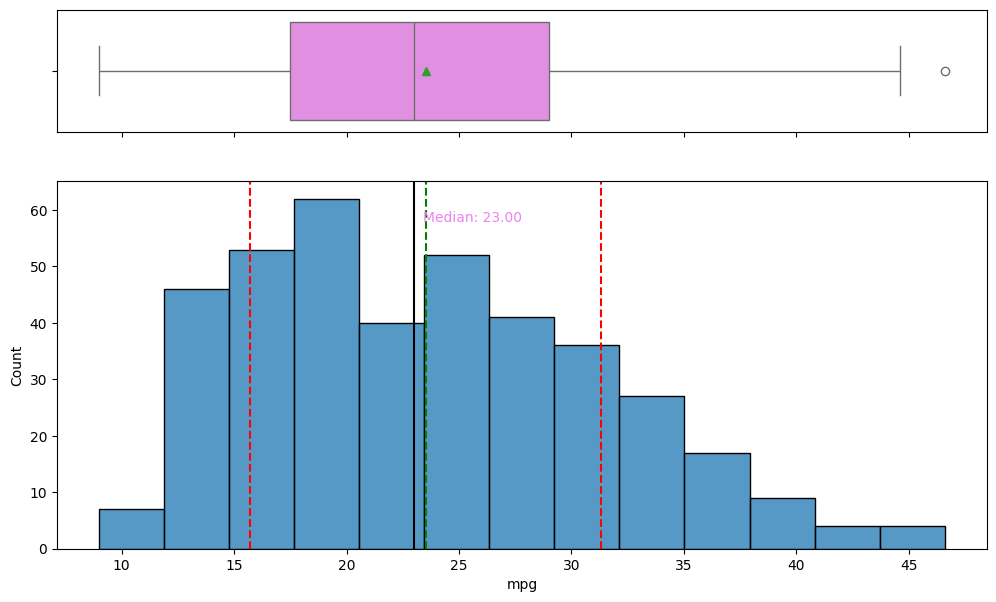

In [ ]:
histogram_boxplot(df, 'mpg')

The graph shows the distribution of the mpg across all models. The graph is approaching a roughly normal distribution, but is slighlty right skewed. The largest number of vehicles can get roughly just over 20 mpg. The red lines indicate the standard deviation from the mean. The green line indicates the mean and the violet line indicates the median.

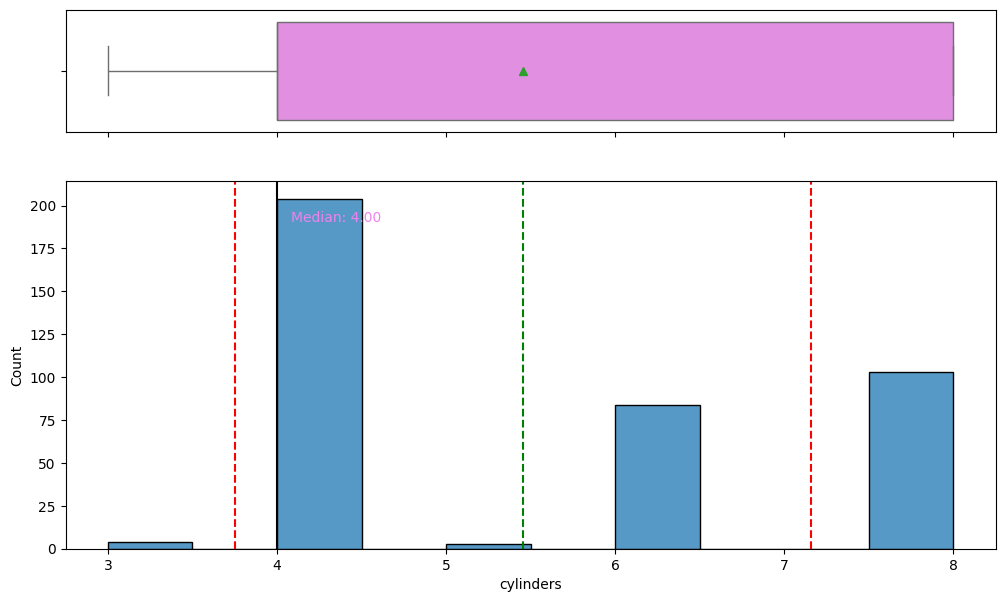

In [ ]:
histogram_boxplot(df, 'cylinders')

The graph shows that most of the vehicles in the data set are 4-cylinder engine models, followed by 8- and 6-cylinder engine models, respectively.

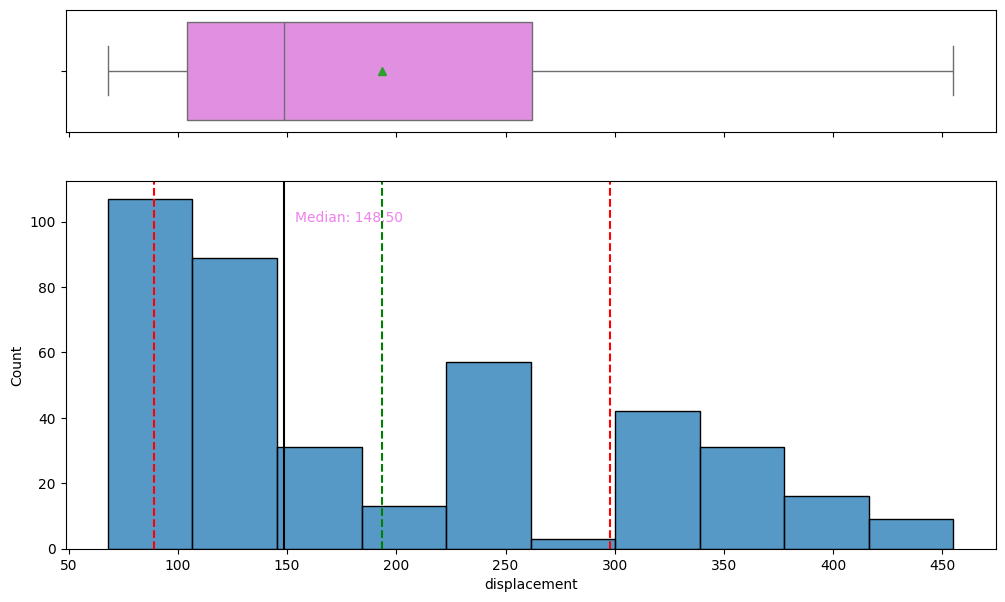

In [ ]:
histogram_boxplot(df, 'displacement')

The graph shows the displacement for models across the data set. The distribution is right skewed and that has impacted our mean value in this instance, as the larger number of vehicles actually have displacement well below the mean.

float64


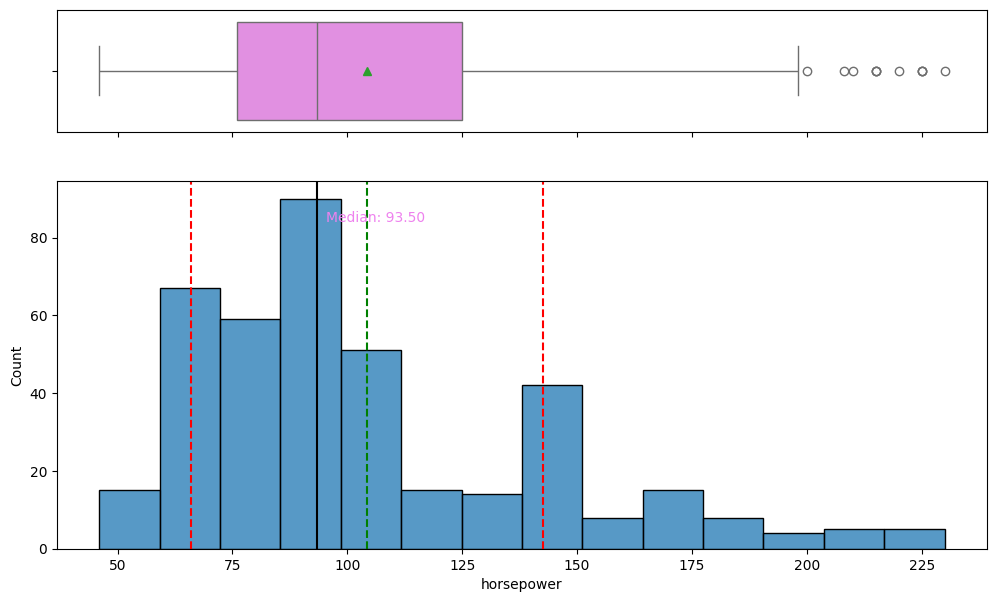

In [ ]:
# Replace '?' with NaN and convert 'horsepower' to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Impute missing 'horsepower' values with the median
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

# Re-check the datatype of 'horsepower'
print(df['horsepower'].dtype)

# Now, plot the histogram and boxplot
histogram_boxplot(df, 'horsepower')

The chart shows the horsepower range for models across the data set. Again, the data is right skewed due to the larger outliers, shifting the mean. We can observe that the majority of the models have less than 100 horsepower.

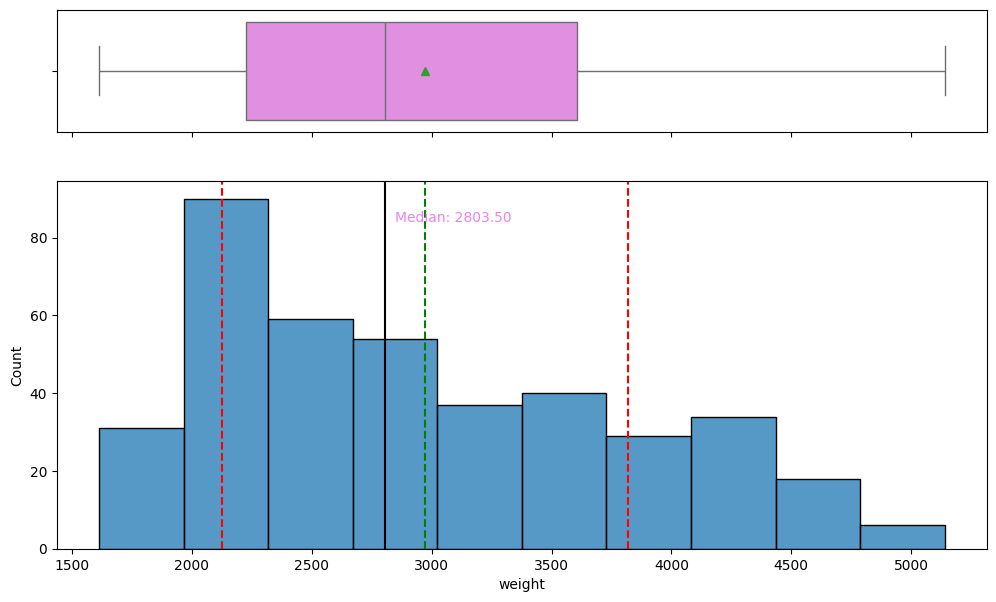

In [ ]:
histogram_boxplot(df, 'weight')

The chart is right skewed, and we can observe that the largest portion of vehicle models range from roughly 1700-3000.

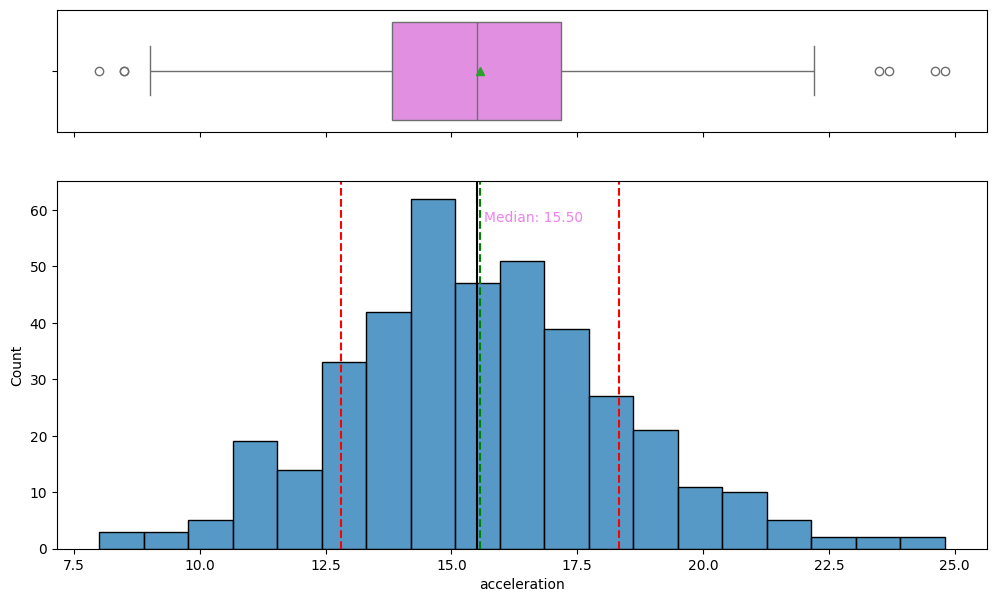

In [ ]:
histogram_boxplot(df, 'acceleration')

The chart for acceleration approaches a fairly normal distribution. The average mpg for the dataset based on the summary statistics was around 23 mpg, while this chart shows the mean value somewhere closer to 16 mpg, which makes sense considering the older model cars in the data set.

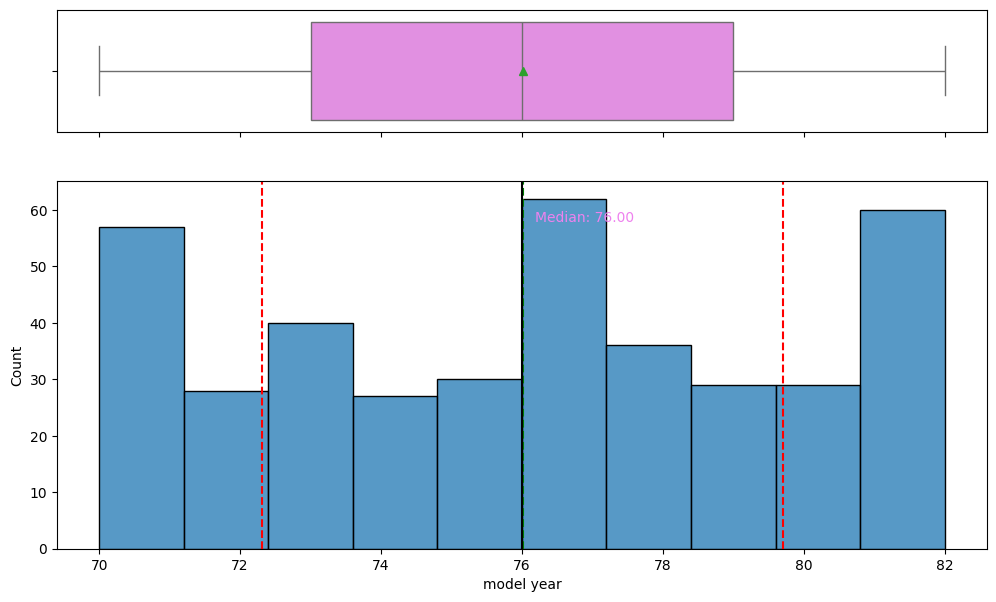

In [ ]:
histogram_boxplot(df, 'model year')


The chart above breaks down how many models are being compared per model year, with more models representing the beginning, middle, end of the range.

Identify and drop outliers

In [ ]:
df_no_outliers = df.copy()
outlier_indices = []

numerical_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
for col in numerical_cols:
  Q1 = df_no_outliers[col].quantile(0.25)
  Q3 = df_no_outliers[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Identify the outliers for the current column
  col_outliers= df_no_outliers[(df_no_outliers[col] < lower_bound) | (df_no_outliers[col] > upper_bound)].index
  outlier_indices.extend(col_outliers)

# Remove duplicate indices from the list of outliers
outlier_indices = list(set(outlier_indices))
print(f"Total number of outliers: {len(outlier_indices)}")

# Drop the outliers from the DataFrame
df_no_outliers = df_no_outliers.drop(outlier_indices). reset_index(drop=True)

Total number of outliers: 18


In [ ]:
# Display first few rows of the DataFrame without the outliers.
display(df_no_outliers.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino


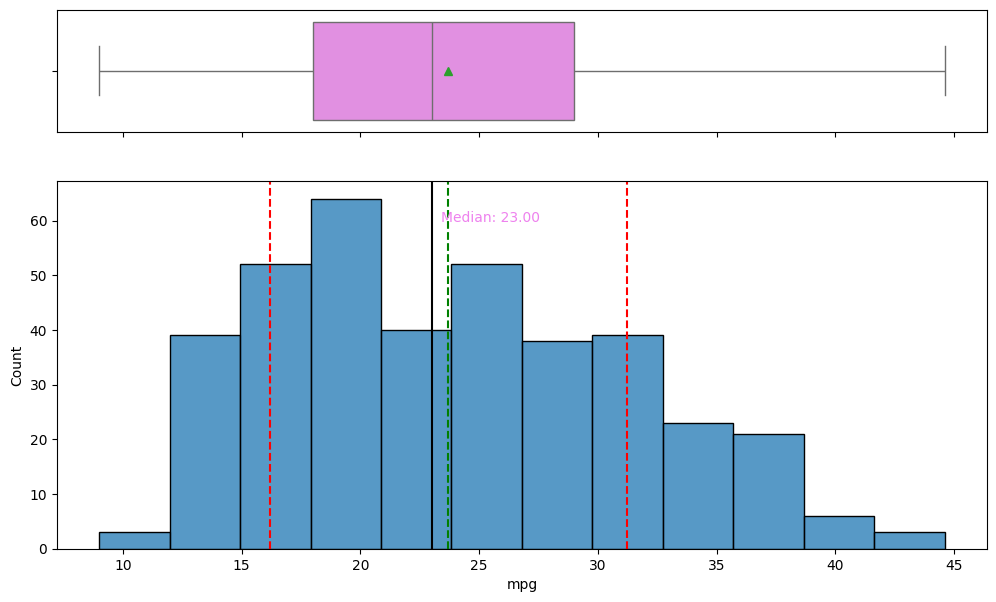

In [ ]:
histogram_boxplot(df_no_outliers, 'mpg')

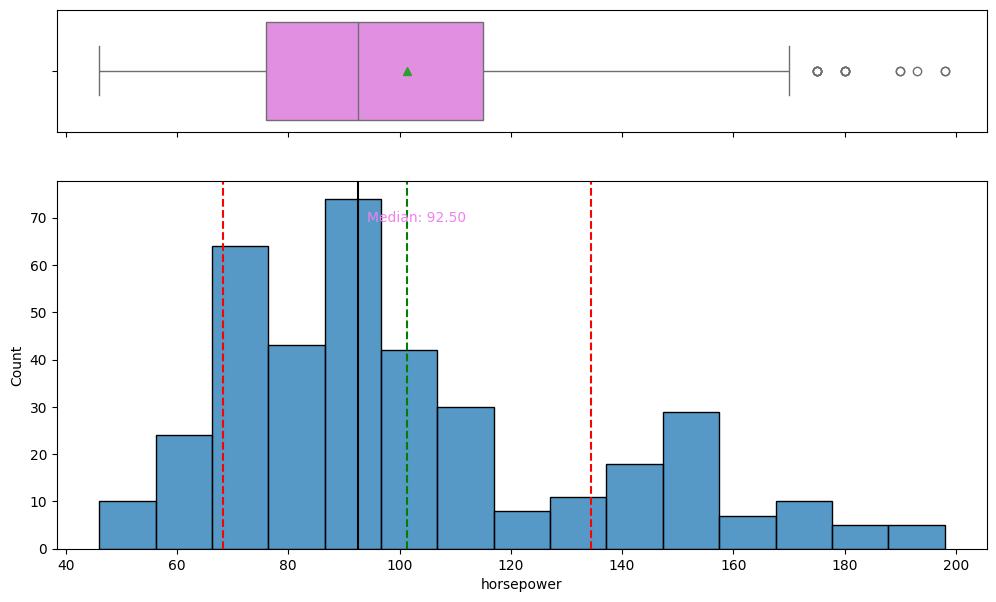

In [ ]:
histogram_boxplot(df_no_outliers, 'horsepower')


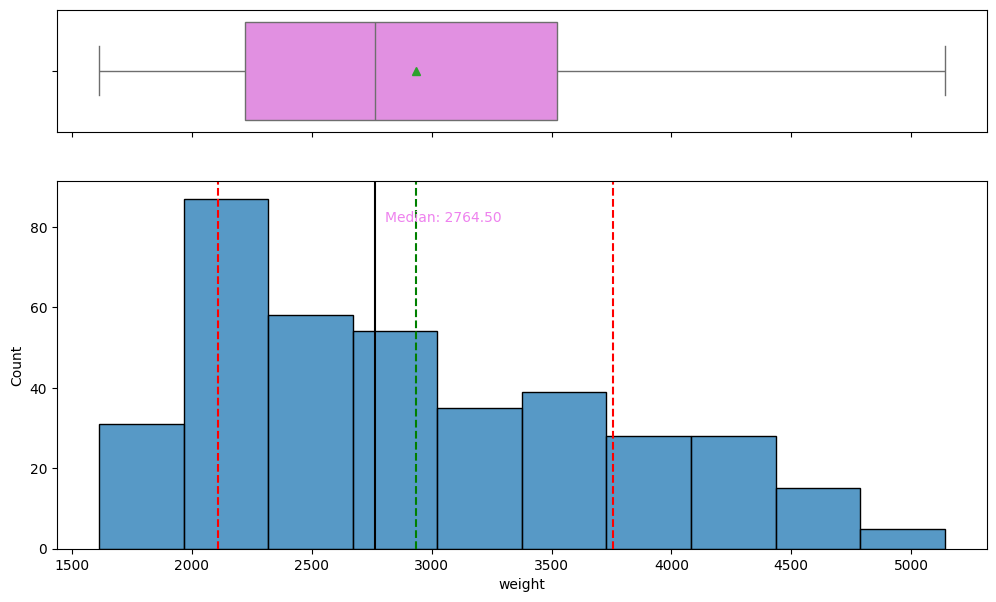

In [ ]:
histogram_boxplot(df_no_outliers, 'weight')


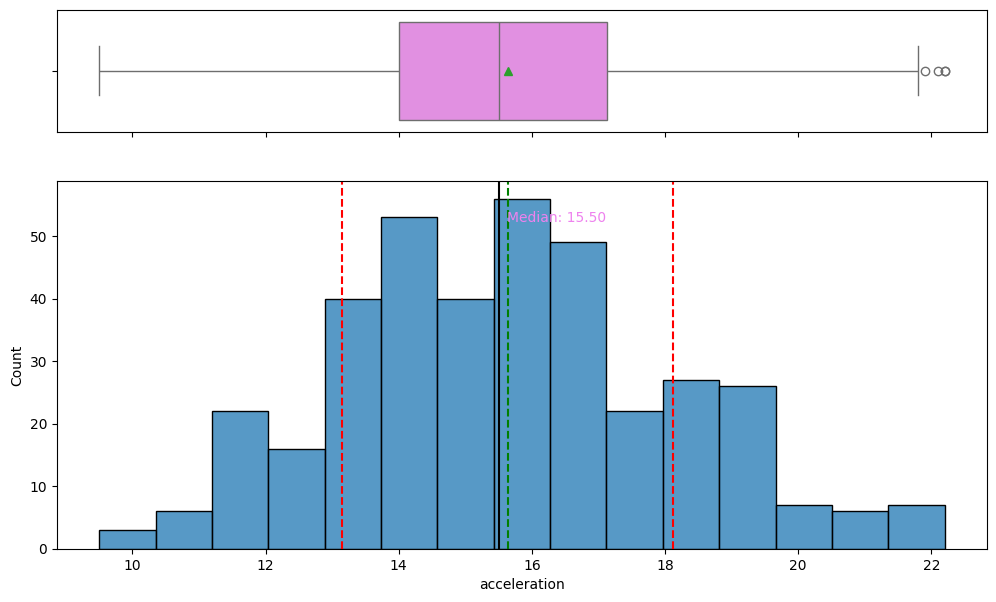

In [ ]:
histogram_boxplot(df_no_outliers, 'acceleration')


# Bar Plots

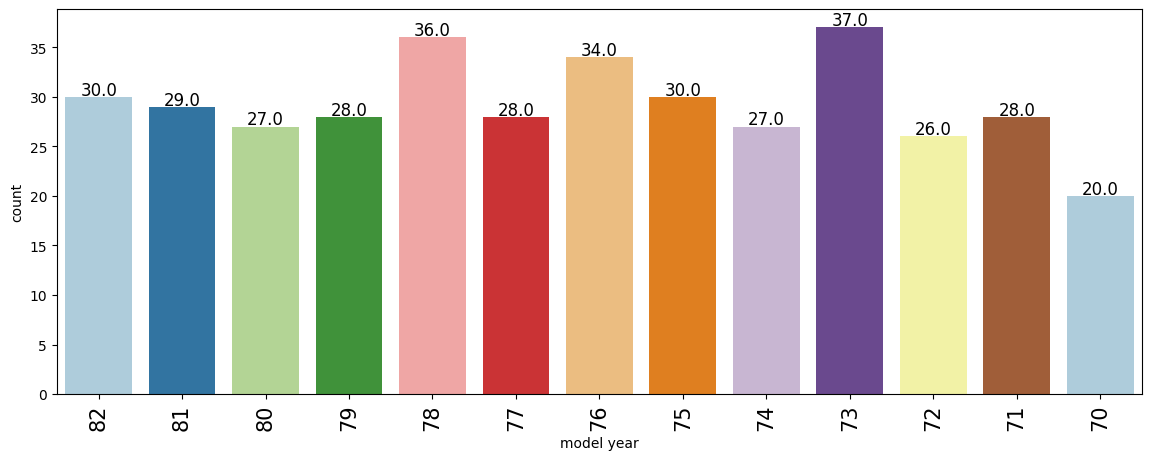

In [ ]:
labeled_barplot(df_no_outliers, 'model year')

This bar plot gives the number of models being compared for each model year.

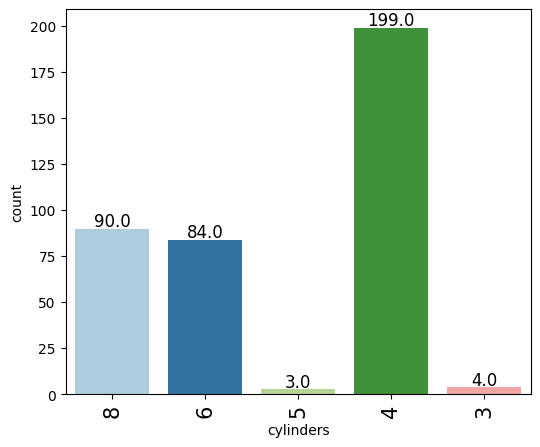

In [ ]:
labeled_barplot(df_no_outliers, 'cylinders')

This barplot shows the amount of vehicle models that are 3,4,5,6, and 8 cylinder engines, respectively. The largest amount of vehicles are 4 cylinder engines, followed by 8 and 6, respectively.

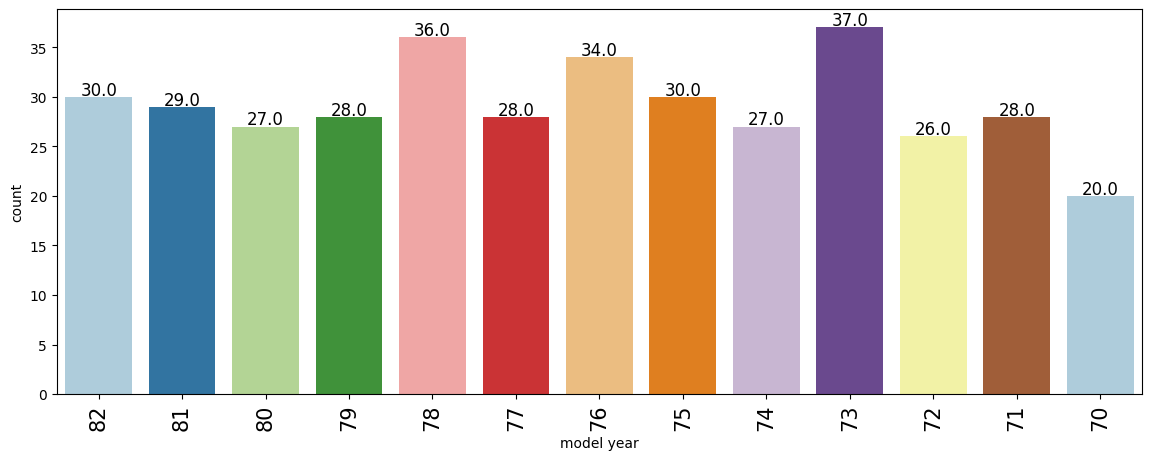

In [ ]:
labeled_barplot(df_no_outliers, 'model year')

### **Separating 'make' and 'model' from 'car name'**

There may be some value in understanding the breakdown of the brands of car, so I have created a new column for the make of the vehicles.

In [ ]:
# Split the 'car name' column into 'make' and 'model'
# We use n=1 to split only at the first space and expand=True to create new columns
df[['make', 'model']] = df['car name'].str.split(' ', n=1, expand=True)

# Display the first few rows with the new columns
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,make,model
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,chevrolet,chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,buick,skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,plymouth,satellite
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,amc,rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,ford,torino


### **Fixing typos in a categorical column**

There are some typos in the make category that need to be corrected. For instance, 'chevroelt' and 'chevy' might actually refer to 'chevrolet', 'vw' to 'volkswagen', 'maxda' to 'mazda', 'mercedes' to 'mercedes-benz', 'toyouta' to 'toyota', and 'vokswagen' to 'volkswagen'.

In [ ]:
# Step 1: Identify unique values and their counts to spot typos
display(df['make'].value_counts())

# Step 2: Define a mapping for corrections
correction_map = {
    'chevroelt': 'chevrolet',
    'chevy': 'chevrolet',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda',
    'mercedes': 'mercedes-benz',
    'toyouta': 'toyota'
}

# Step 3: Apply the corrections to the 'make' column
df['make'] = df['make'].replace(correction_map)

# Verify the corrections
display(df['make'].value_counts())

,count
make,
ford,51
chevrolet,43
plymouth,31
amc,28
dodge,28
toyota,25
datsun,23
buick,17
pontiac,16


,count
make,
ford,51
chevrolet,47
plymouth,31
amc,28
dodge,28
toyota,26
datsun,23
volkswagen,22
buick,17


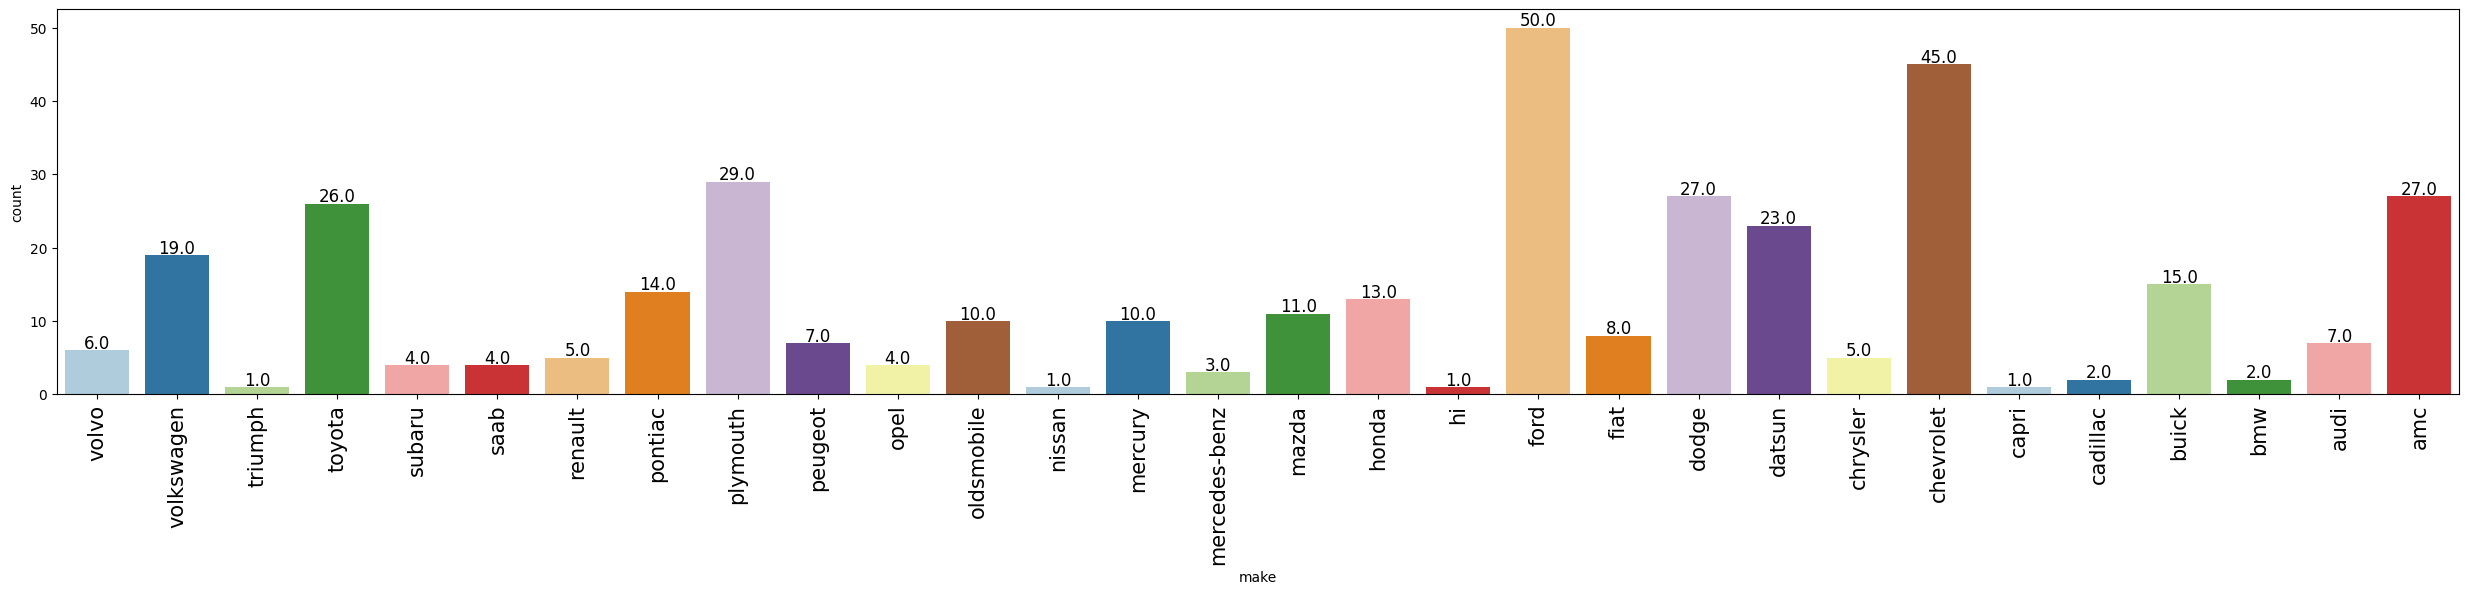

In [ ]:
# Split the 'car name' column into 'make' and 'model' for df_no_outliers
df_no_outliers[['make', 'model']] = df_no_outliers['car name'].str.split(' ', n=1, expand=True)

# Define a mapping for corrections
correction_map = {
    'chevroelt': 'chevrolet',
    'chevy': 'chevrolet',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda',
    'mercedes': 'mercedes-benz',
    'toyouta': 'toyota'
}

# Apply the corrections to the 'make' column in df_no_outliers
df_no_outliers['make'] = df_no_outliers['make'].replace(correction_map)

# Now plot the barplot
labeled_barplot(df_no_outliers, 'make', n=len(df_no_outliers['make'].unique()))

This chart shows the number of models from each brand, with the corrections made for typos in brand names. The brands with the highest model representation are Ford, Chevrolet, Plymouth, AMC, Dodge, Toyota, and Volkswagen.

## Bivariate Analysis



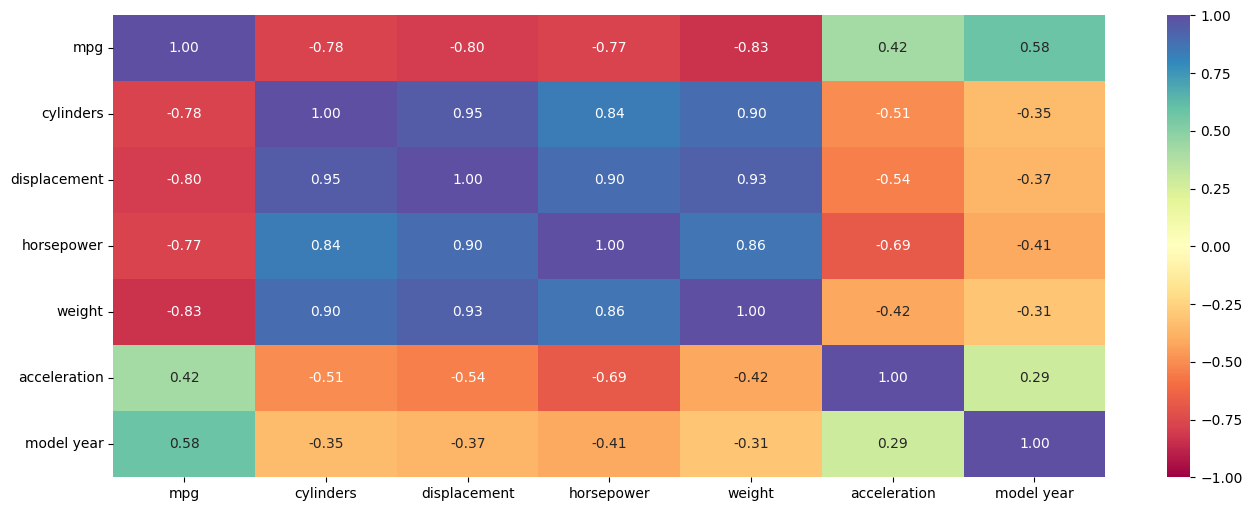

In [ ]:
# Correlation check
cols_list= df_no_outliers.select_dtypes(include = np.number).columns.tolist()
plt.figure(figsize = (16, 6))
sns.heatmap(df[cols_list].corr(), annot = True, vmin= -1, fmt ='.2f',  cmap = "Spectral")
plt.show()

We can see a large number of variables that show a high correlation with one another. The variables named cylinders, displacement, horsepower, and weight are all highly correlated, which makes sense due to each being a contributing component of the performance of an engine. We can also see that acceleration is moderately correlated to both model year and mpg. The weight and displacement variables are most negatively correlated with the mpg variable.

<function matplotlib.pyplot.show(close=None, block=None)>

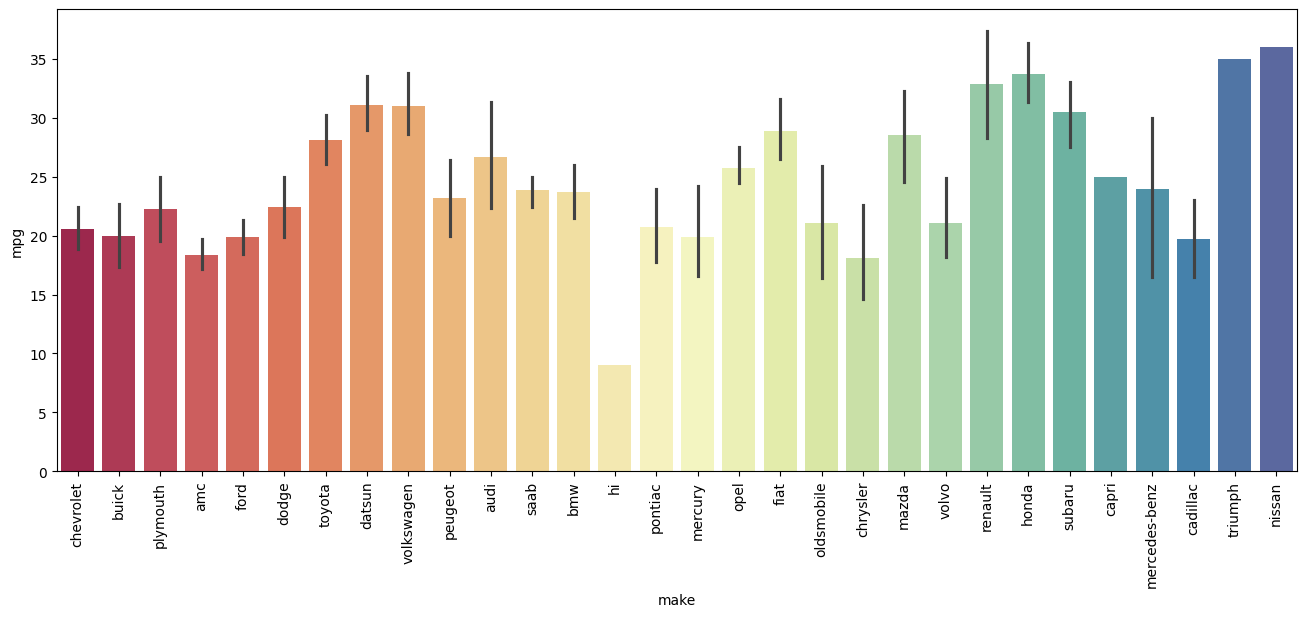

In [ ]:

plt.figure(figsize = (16, 6))
sns.barplot(data = df_no_outliers, x = 'make', y = 'mpg', palette = "Spectral")
plt.xticks(rotation = 90)
plt.show

There are a couple of important considerations to make about this chart. The first being the columns that have no black line represent only one car. That one car may have high gas mileage, but it is likely that if more models of that brand had been averaged in, the score would probably be lower. The second being that the black lines represent the variance in the mean of each brand's average mpg across all models. Disregarding the highest numbers for Triumph and Nissan, since they each only represent one car, we can see the top three brands with the highest average mpg across all models in the data set are Honda, Renault, and Volkswagen.

<function matplotlib.pyplot.show(close=None, block=None)>

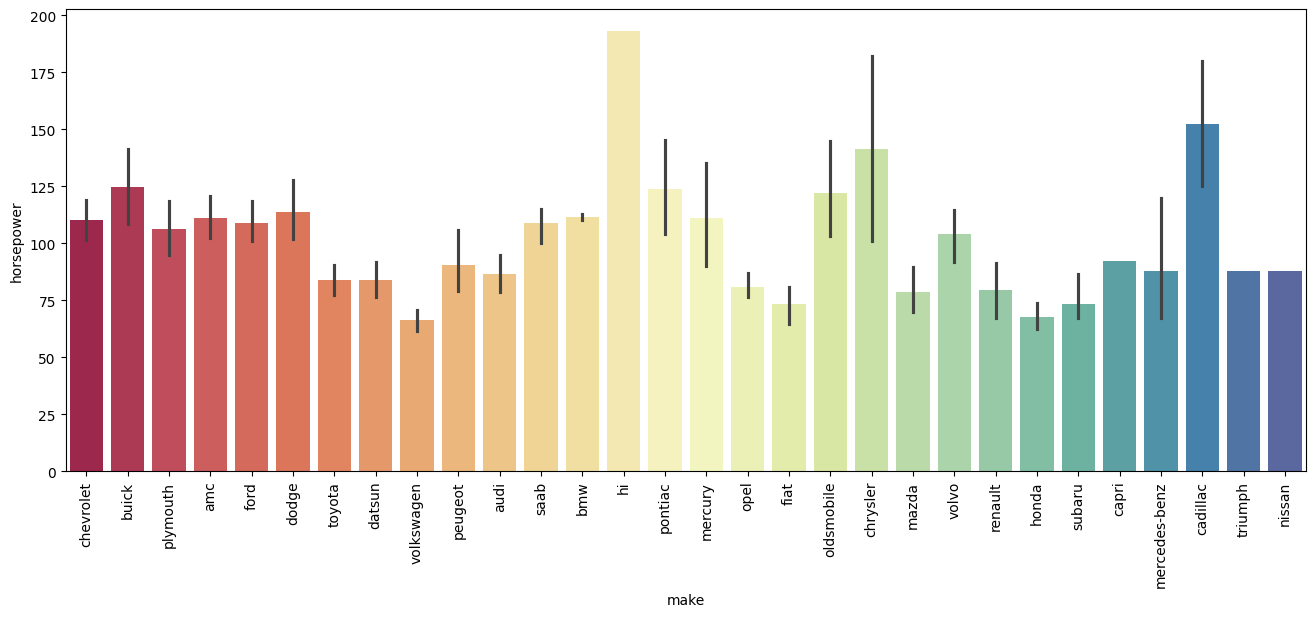

In [ ]:
plt.figure(figsize = (16, 6))
sns.barplot(data = df_no_outliers, x = 'make', y = 'horsepower', palette = "Spectral")
plt.xticks(rotation = 90)
plt.show

From this chart we can observe that the brands who average the most horsepower across all models contained in the dataset are Chrysler, Cadillac, Pontiac, Buick and Mercury.

<function matplotlib.pyplot.show(close=None, block=None)>

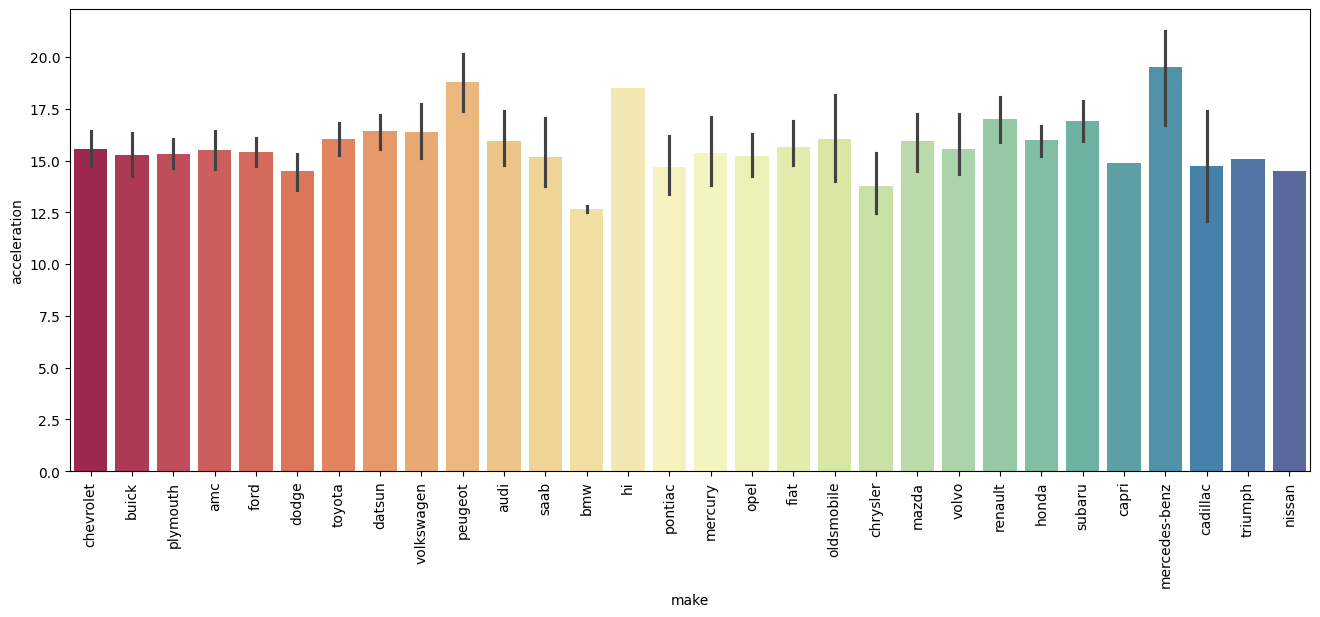

In [ ]:
plt.figure(figsize = (16, 6))
sns.barplot(data = df_no_outliers, x = 'make', y = 'acceleration', palette = "Spectral")
plt.xticks(rotation = 90)
plt.show

We can see that the brands who average the highest acceleration numbers are Mercedes-Benz, Peugeot, Volkswagen, Renault, and Subaru.

<function matplotlib.pyplot.show(close=None, block=None)>

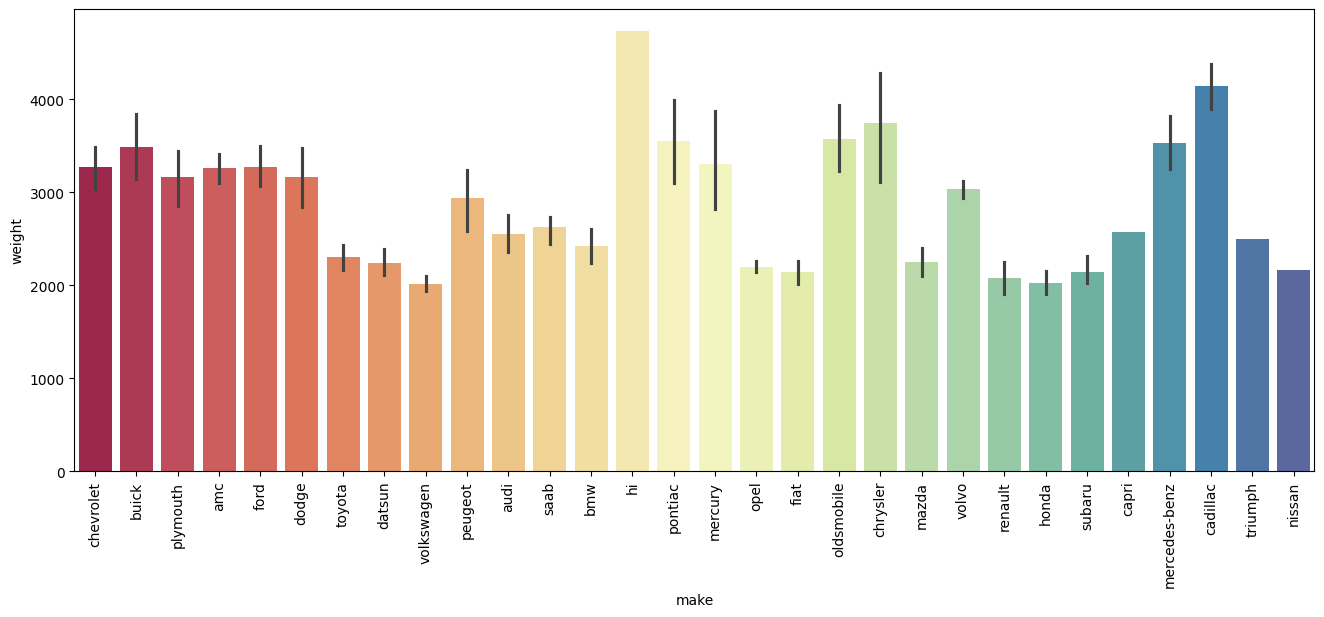

In [ ]:
plt.figure(figsize = (16, 6))
sns.barplot(data = df_no_outliers, x = 'make', y = 'weight', palette = "Spectral")
plt.xticks(rotation = 90)
plt.show

We can observe the top five brands whose models weigh most on average across all models in the data set are Cadillac, Chrysler, Pontiac, Oldsmobile, and Buick.

<function matplotlib.pyplot.show(close=None, block=None)>

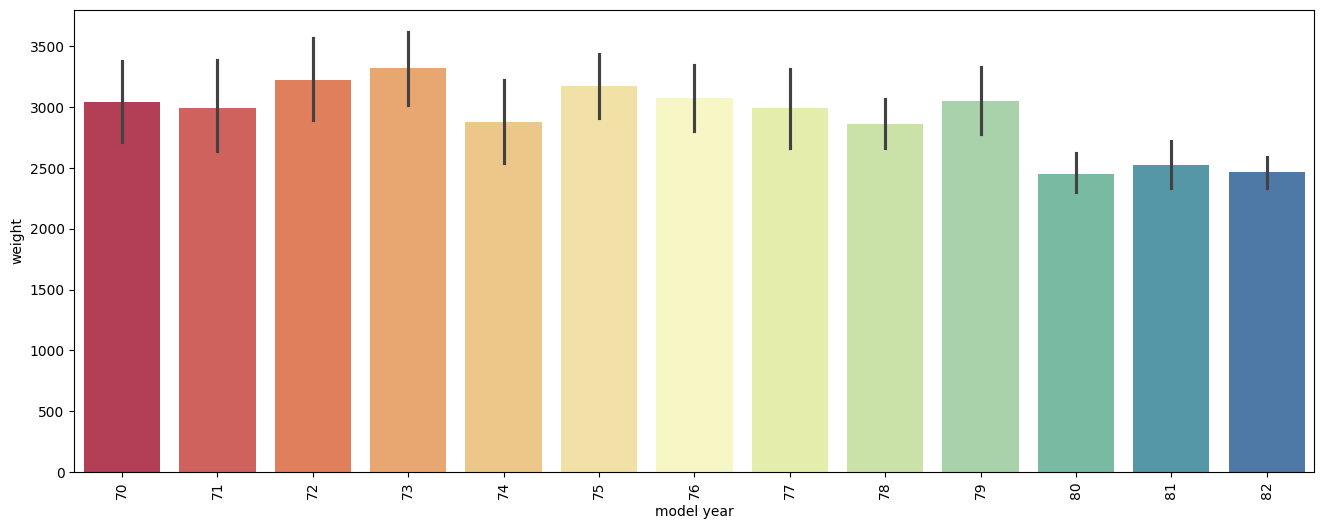

In [ ]:
plt.figure(figsize = (16, 6))
sns.barplot(data = df_no_outliers, x = 'model year', y = 'weight', palette = "Spectral")
plt.xticks(rotation = 90)
plt.show

We can start to see a possible trend in the weight of the cars becoming less and less over time with some exceptions.

### **Scaling the data**

In [ ]:
#Scaling the data before clustering
scaler = StandardScaler()
numerical_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
subset = df[numerical_cols].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init="auto")
kmeans.fit(subset_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
cluster_labels = kmeans.labels_
print(cluster_labels[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.decomposition import PCA


In [ ]:
# Calculate silhouette score
silhouette_avg = silhouette_score(subset_scaled, cluster_labels)
print(f"The Silhouette Score for 3 clusters is: {silhouette_avg:.2f}")

The Silhouette Score for 3 clusters is: 0.35


The Silhouette score is 0.35, which is an acceptable score for clustering, but it may be possible to increase the score using DBSCAN.


## DBSCAN


In [ ]:
# Transform the scaled data using the PCA model
pca_transformed = pca.transform(subset_scaled)

# Create a DataFrame with the first two principal components
pca_2d_df = pd.DataFrame(data=pca_transformed[:, :2], columns=['PC1', 'PC2'])

# Display the first few rows of the pca_2d_df
display(pca_2d_df.head())

,PC1,PC2
0,2.661556,-0.918577
1,3.523307,-0.789779
2,2.998309,-0.861604
3,2.937560,-0.949168
4,2.930688,-0.931822


In [ ]:
# Implement DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1, min_samples=4)
dbscan_labels = dbscan.fit_predict(subset_scaled)

# Count number of clusters found(excluding noise points, which are labeled -1)
num_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters using DBSCAN: {num_dbscan_clusters}")
print(f"DBSCAN Cluster lables(first 10): {dbscan_labels[:10]}")

# Calculate Silhouette Score for DBSCAN if more than one cluster and not all noise
if num_dbscan_clusters > 1 and len(dbscan_labels) > 1:
  dbscan_silhouette_avg = silhouette_score(subset_scaled, dbscan_labels)
  print(f"The Silhouette Score for DBSCAN is: {dbscan_silhouette_avg:.2f}")
else:
  print("Cannot calculate Silhouette Score: Not enough clusters or all points are noise. ")

Number of clusters using DBSCAN: 2
DBSCAN Cluster lables(first 10): [0 0 0 0 0 0 0 0 0 0]
The Silhouette Score for DBSCAN is: 0.38


Visualize DBSCAN on PCA Plot

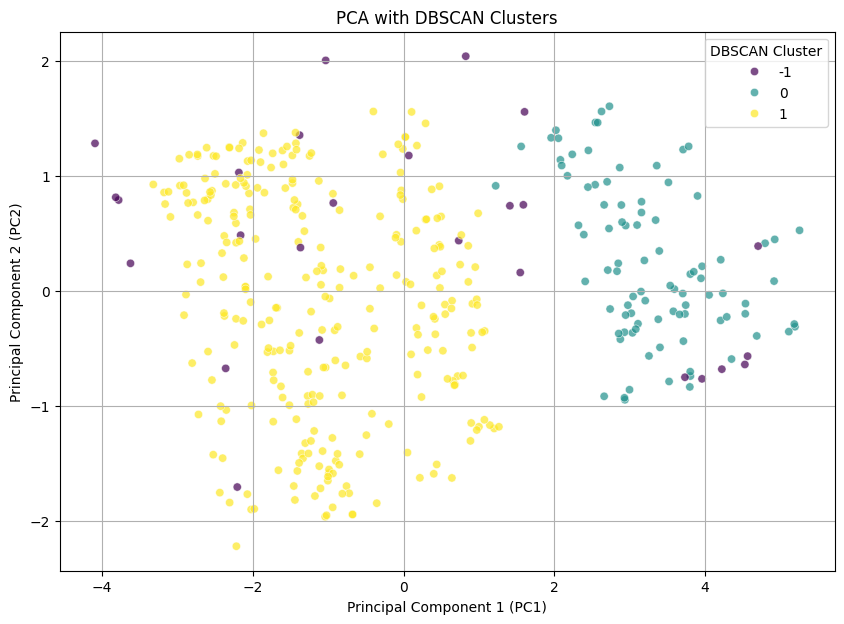

In [ ]:
pca_2d_df['DBSCAN_Cluster'] = dbscan_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data = pca_2d_df, palette= 'viridis', alpha=0.7)
plt.title('PCA with DBSCAN Clusters')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='DBSCAN Cluster')
plt.show()

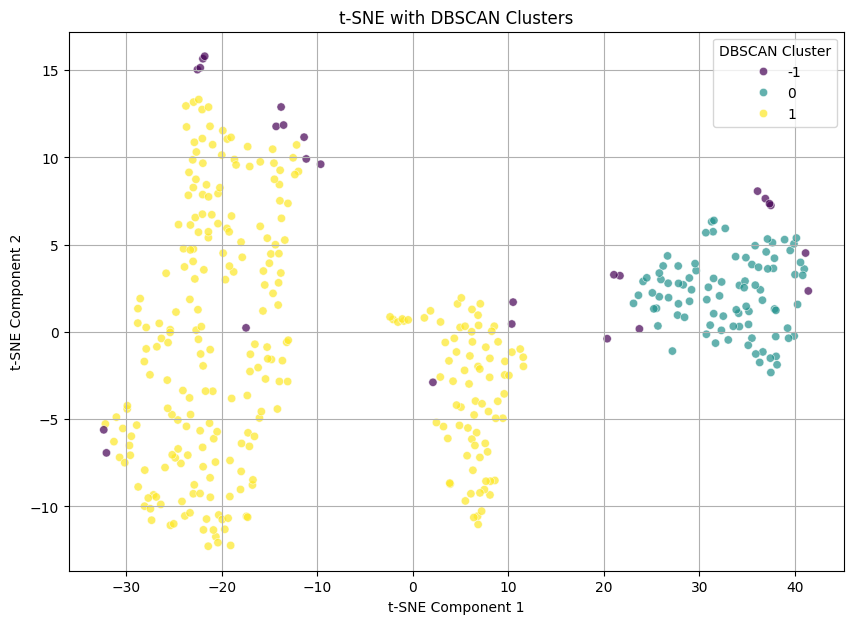

In [ ]:
# Add DBSCAN cluster labels to the t-SNE DataFrame
tsne_df["DBSCAN_Cluster"] = dbscan_labels

# Visualize the data with DBSCAN clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='DBSCAN_Cluster', data = tsne_df, palette= 'viridis', alpha=0.7)
plt.title('t-SNE with DBSCAN Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='DBSCAN Cluster')
plt.show()

## **Principal Component Analysis**

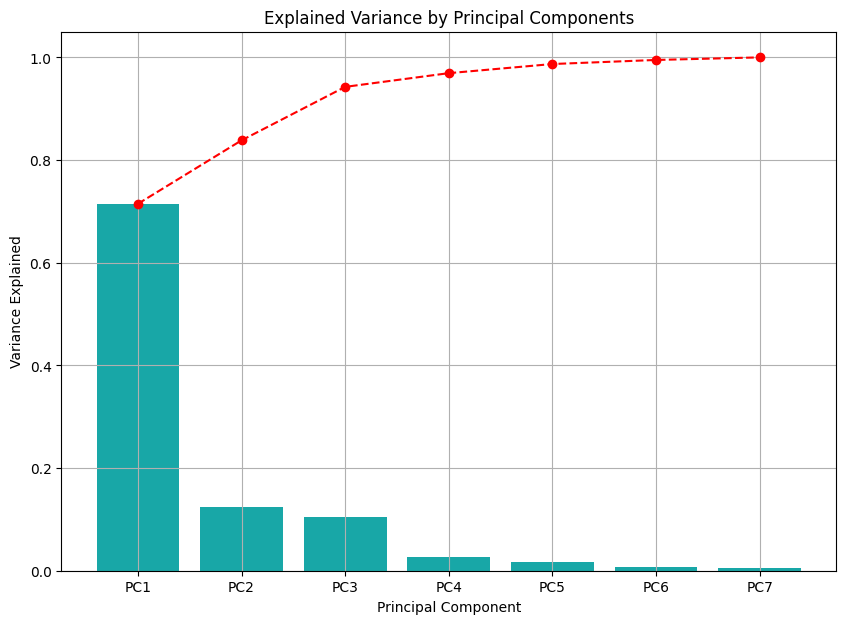

In [ ]:
# Perform PCA
pca = PCA()
pca.fit(subset_scaled)

# Get explained variance ratio
exp_var_ratio = pca.explained_variance_ratio_

#Create a dataframe for explained variance
pca_df = pd.DataFrame(
    {"PC": ["PC" + str(i) for i in range(1, len(exp_var_ratio) + 1)],
     "Variance Explained": exp_var_ratio,
     "Cumulative Variance": exp_var_ratio.cumsum()})

# Plot explained variance
plt.figure(figsize = (10, 7))
sns.barplot(data = pca_df, x = "PC", y = "Variance Explained", color = "c")
plt.plot(pca_df["PC"], pca_df["Cumulative Variance"], marker = "o", linestyle = "--", color = "r")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by Principal Components")
plt.grid(True)

Observations: The first three principal components account for about 94% of the variance in the data.

#### **Interpret the coefficients of the first three principal components from the below DataFrame**

In [ ]:
# Get the principal components (loadings)
loadings = pca.components_

# Create a DataFrame for the loadings
loadings_df = pd.DataFrame(
    loadings.T,
    columns = ["PC" + str(i) for i in range(1, loadings.shape[0] + 1)],
    index = subset.columns
)

# Display the loadings for the first three principal components
print("Loadings (Coefficients) of the first three Principal Components:")
display(loadings_df.iloc[:, :3])

Loadings (Coefficients) of the first three Principal Components:


,PC1,PC2,PC3
mpg,-0.397737,0.211430,-0.256579
cylinders,0.416485,0.191612,0.140786
displacement,0.429713,0.177428,0.103649
horsepower,0.422311,0.090327,-0.168064
weight,0.414224,0.221956,0.279668
acceleration,-0.284828,-0.024110,0.892645
model year,-0.229428,0.910548,-0.018109


Observations:  PC1 has strong positive coefficients for features like 'displacement', 'horsepower', and 'weight'. This suggests that these are heavier vehicles that are less fuel efficient. PC2 has a strong positive coefficient for the 'model year' feature, suggesting that PC2 is highly related to the modernity of the car. PC3 has a strong positive coefficient for 'acceleration' and a moderate positive loading for 'weight', suggesting that it may be capturing aspects of the car's acceleration capabilities and how the weight impacts that. Its overall explained variance is less than PC1 and PC2, so its influence is smaller.

#### **Visualize the data in 2 dimensions using the first two principal components**



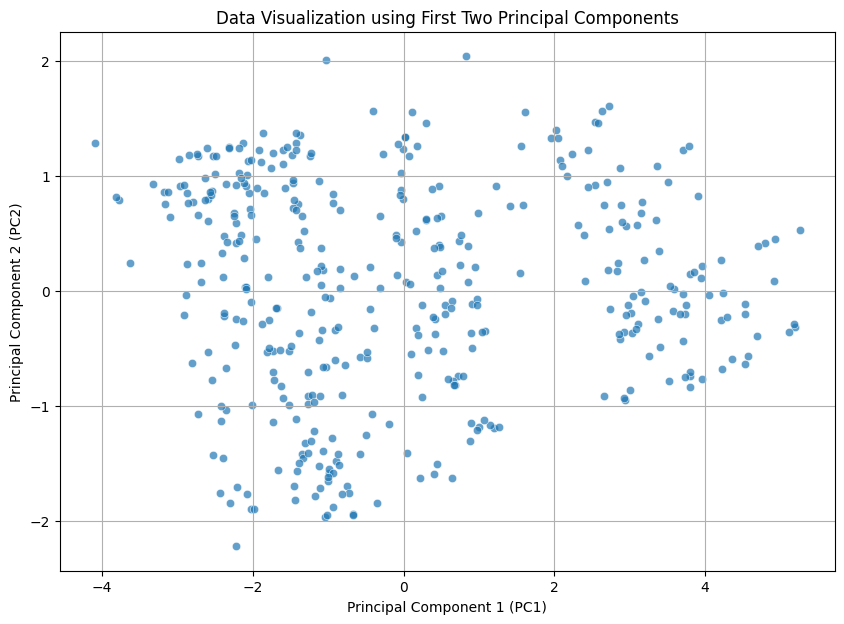

In [ ]:
# Transform the scaled data using the PCA model
pca_transformed = pca.transform(subset_scaled)

# Create a DataFrame with the first two principal components
pca_2d_df = pd.DataFrame(data=pca_transformed[:, :2], columns=['PC1', 'PC2'])

# Visualize the data in 2 dimensions
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=pca_2d_df, alpha=0.7)
plt.title('Data Visualization using First Two Principal Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()

Observations: The higher an x value for PC1 and the lower the y value, the higher the likelihood the vehicle is an older, heavier, less fuel efficient model. Conversely, a higher y value and lower x value will indicate a newer, lighter, more fuel efficient model.  

## **t-SNE**

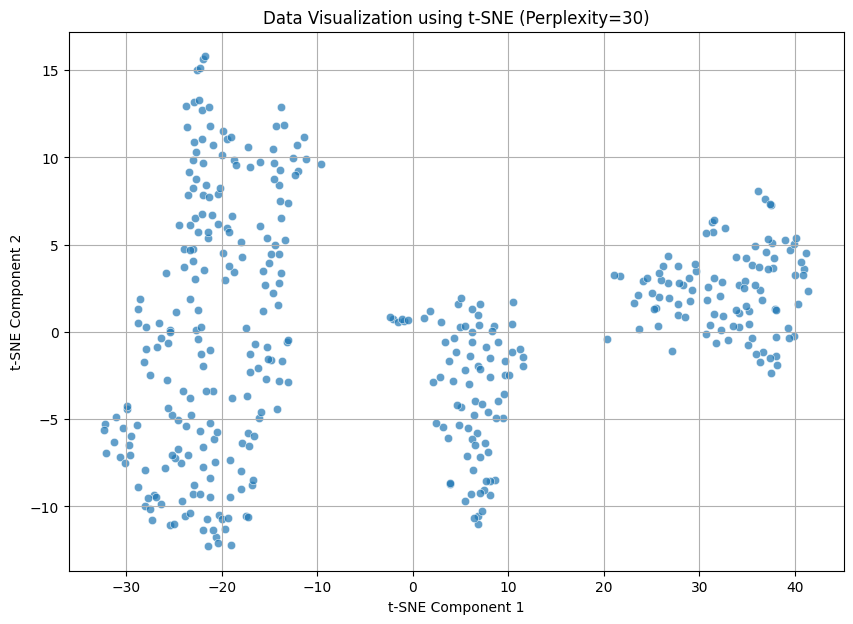

In [ ]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_transformed = tsne.fit_transform(subset_scaled)

# Create a DataFrame for t-SNE results
tsne_df = pd.DataFrame(data=tsne_transformed, columns=['TSNE1', 'TSNE2'])

# Visualize the data in 2 dimensions using t-SNE
plt.figure(figsize=(10, 7))
sns.scatterplot(x='TSNE1', y='TSNE2', data=tsne_df, alpha=0.7)
plt.title('Data Visualization using t-SNE (Perplexity=30)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

We can observe that the data has formed 3 relatively distinct clusters.




#### **Visualize the clusters w.r.t different variables using scatter plot and box plot**

In [ ]:
# Combine original scaled data with cluster labels
df_clustered = pd.DataFrame(subset_scaled,  columns=[f'feature_{i+1}' for i in range(subset_scaled.shape[1])])
df_clustered['Cluster'] = cluster_labels
print(df_clustered.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0  -0.706439   1.498191   1.090604   0.673118   0.630870  -1.295498   
1  -1.090751   1.498191   1.503514   1.589958   0.854333  -1.477038   
2  -0.706439   1.498191   1.196232   1.197027   0.550470  -1.658577   
3  -0.962647   1.498191   1.061796   1.197027   0.546923  -1.295498   
4  -0.834543   1.498191   1.042591   0.935072   0.565841  -1.840117   

   feature_7  Cluster  
0  -1.627426        1  
1  -1.627426        1  
2  -1.627426        1  
3  -1.627426        1  
4  -1.627426        1  


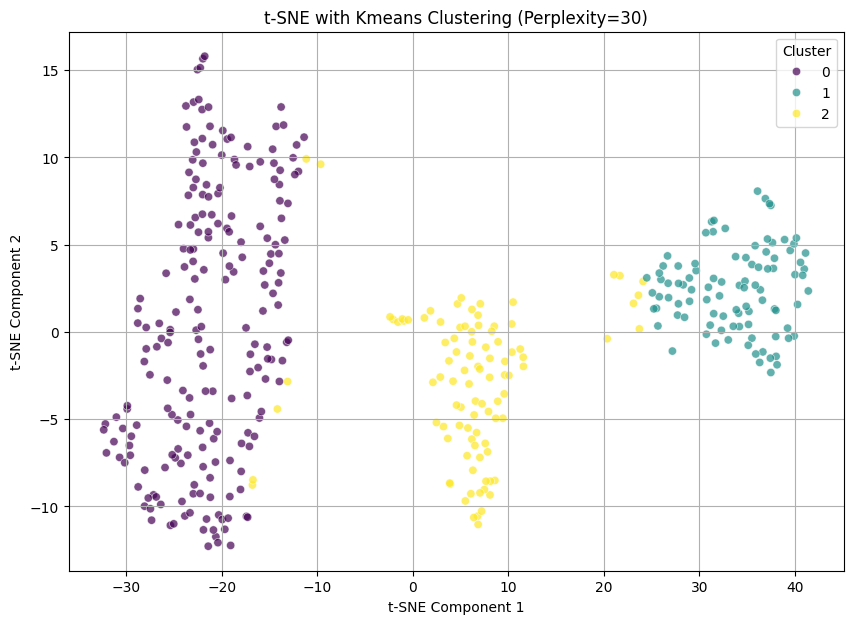

In [ ]:
tsne_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=tsne_df, palette= 'viridis', alpha=0.7)
plt.title('t-SNE with Kmeans Clustering (Perplexity=30)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

Observations:

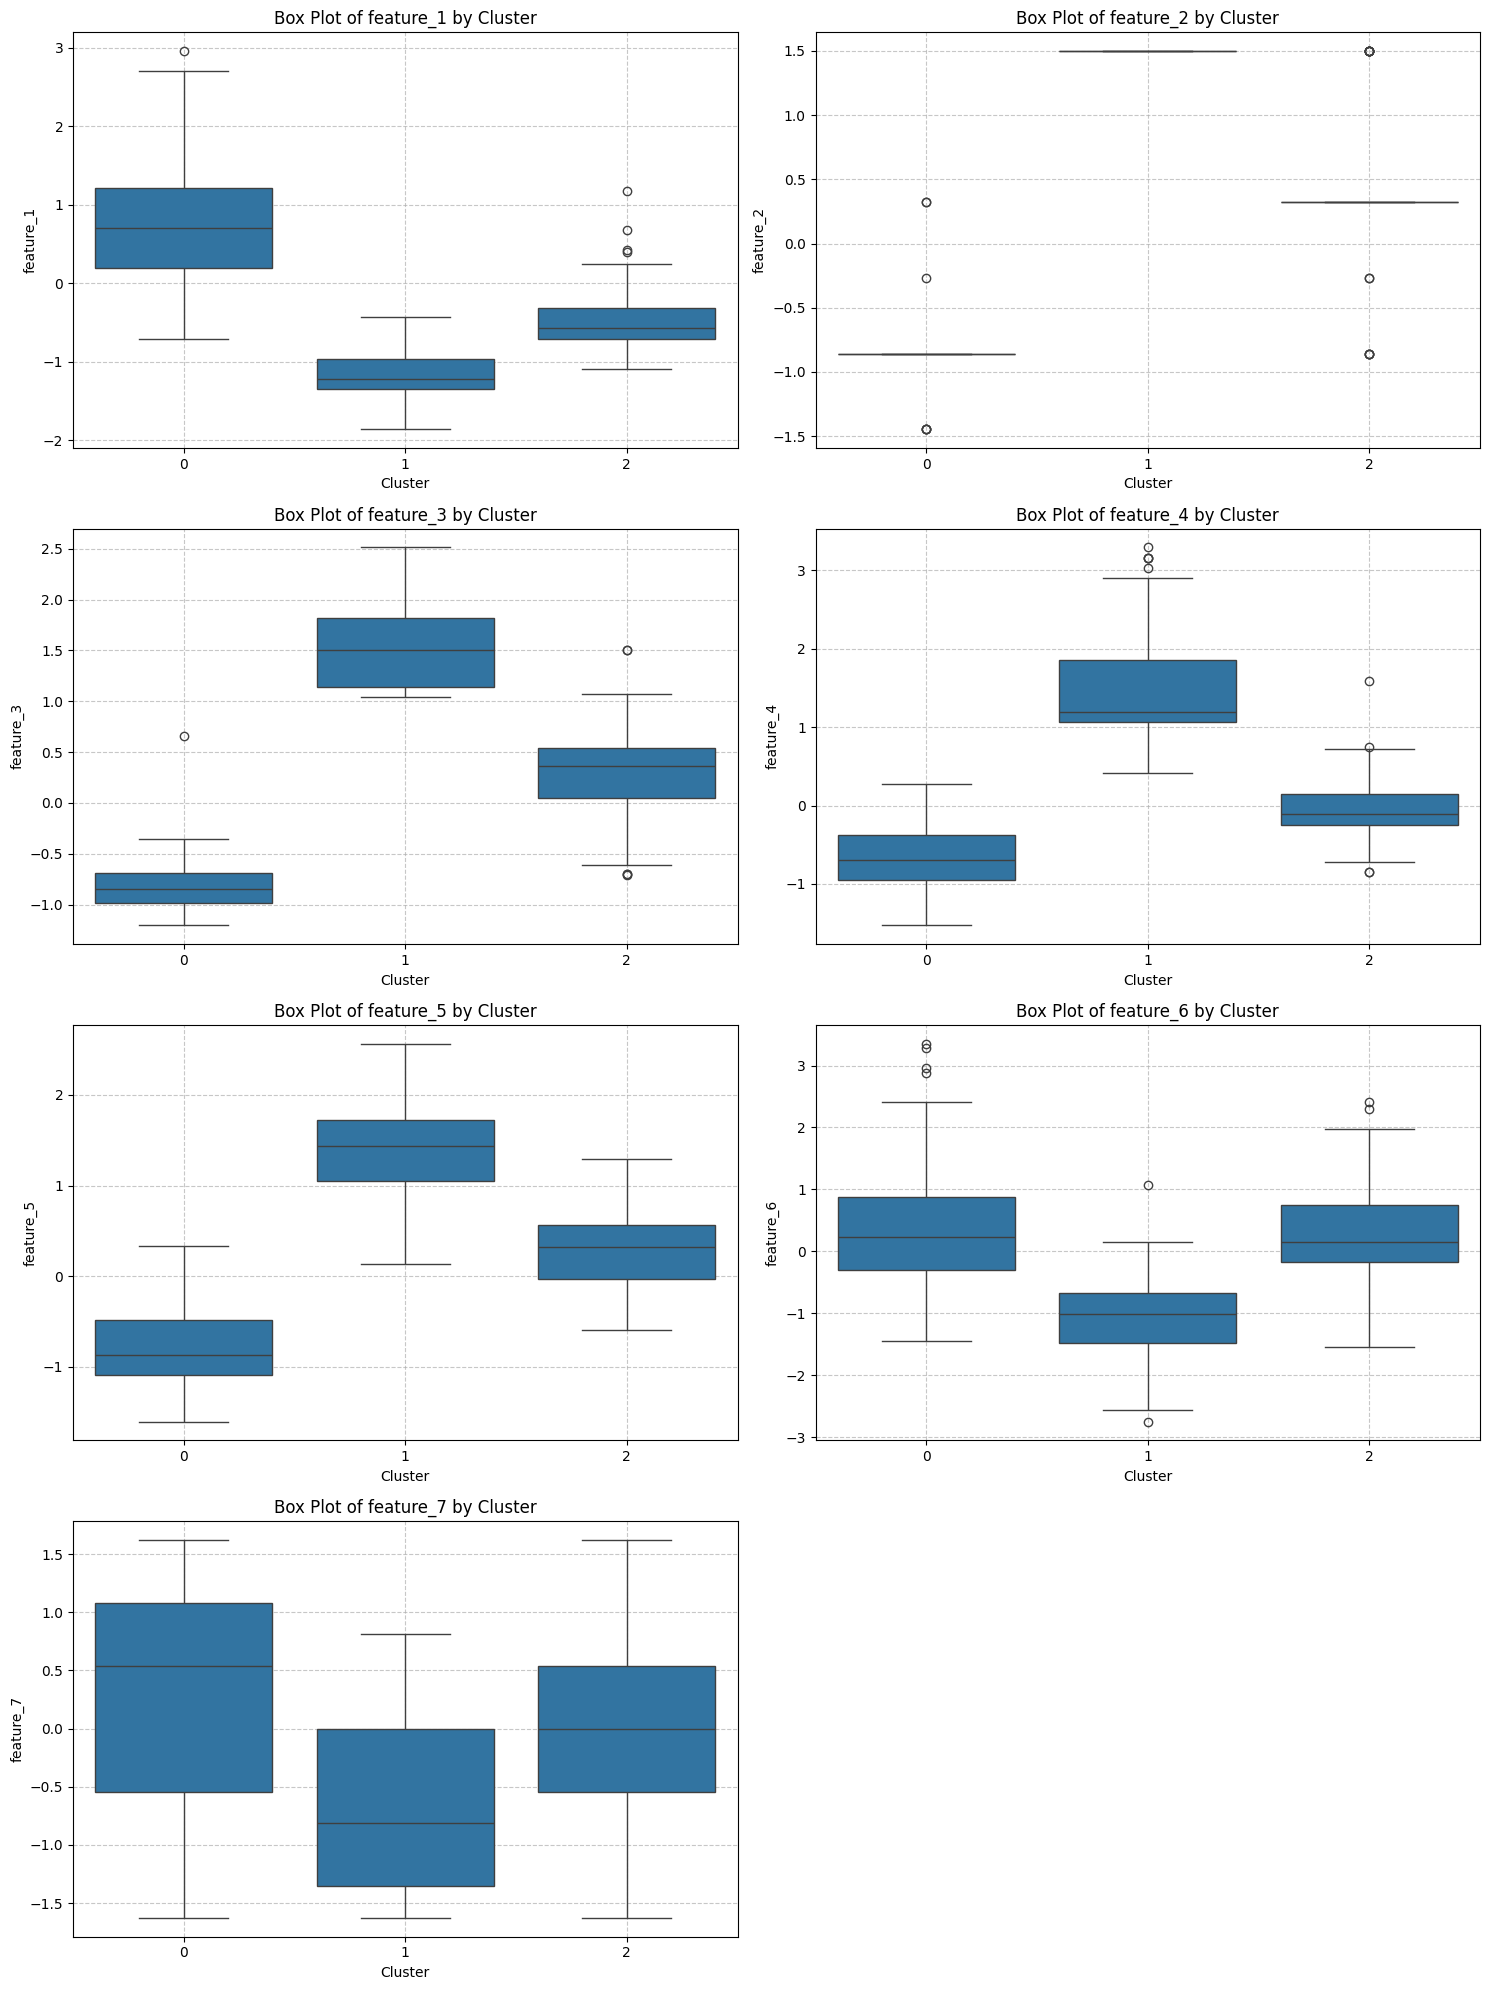

In [ ]:
#get list of feature columns
feature_cols = [col for col in df_clustered.columns if col != 'Cluster']

# determine the number of features to plot on layout
num_features = len(feature_cols)
num_rows = (num_features + 1) // 2

plt.figure(figsize=(15, 5 * num_rows))

for i, feature in enumerate(feature_cols, 1):
    plt.subplot(num_rows, 2, i)
    sns.boxplot(x='Cluster', y=feature, data=df_clustered)
    plt.title(f'Box Plot of {feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Observations:
Cluster 0:


*   mpg: Generally higher mpg, indicating better fuel efficiency
*   cylinders, displacement, horsepower, weight: These variables are significantly lower than average for these features, suggesting that the vehicles may be lighter or have smaller engines.


*  acceleration: Average acceleration time

*  model year: This cluster consists of newer models


*   Overall: This cluster represents newer vehicles that are smaller and lighter with higher fuel efficiency and average acceleration.

Cluster 1:


*   mpg: Significantly lower mpg than cluster 0, indicating subpar fuel efficiency.
*   cylinders, displacement, horsepower, weight: These variables are higher than average for these features, which can be characteristic of larger vehicles with large engines and more cylinders.


*  acceleration: Slower acceleration time.
*  model year: Comprises older models


*   Overall: This cluster is representing heavy, older cars with a larger engine, perhaps muscle cars or large luxury sedans. These vehicles have poor fuel economy and slower acceleration, often with an 8 cylinder engine.  



Cluster 2:


*   mpg: Moderately good mpg
*   cylinders, displacement, horsepower, weight: These variables are generally close to the average which suggests a balance of power and size, often with a 6 or 8 cylinder engine.


*  acceleration: Faster acceleration time.
*  model year: Represents cars from midrange model years.


*   Overall: This cluster represents cars that are well balanced between power and efficiency, as well as comparatively faster acceleration and moderate fuel economy.








## **Actionable Insights and Recommendations**

# Key Findings:

*  Using Kmeans, clustering identified three distinct groups of vehicles. The initial silhouette score of 0.35 was only marginally improved by running DBSCAN to 0.38. There may be room for improvement with additional feature engineering or additional data from the vehicles.
*   The PCA and tSNE visualizations confirmed the presence of the clusters, with tSNE showing a more pronounced separation of the groups.


*   Cluster 0 (Newer, more fuel efficient, smaller): These cars are characterized by models in the late 70s and early 80s with high mpg, small engines, low horsepower, lighter weight, and average acceleration.
*   Cluster 1 (Older, Powerful, Inefficient): These cars are characterized by models in the early 70s with significantly lower mpg, large engines with higher horsepower and displacement, and often higher weight and slower acceleration.


*   Cluster 2 (Mid-range, Balanced Performance) :These cars are characterized by models in the mid 70s, with good fuel economy, balanced weight and power, average engine size, and higher acceleration.

Recommendations:
1) SecondLife can target buyers who are environmentally conscious for vehicles in Cluster 0. Marketing can focus in on demographics that commute, or those who prefer vintage vehicles with better fuel economy. Marketing could emphasize fuel savings, highlight the ease of maneuverability of these smaller cars, and appeal to buyers with a "classic, yet sensible" aesthetic.
2) SecondLife should target buyers of vehicles in Cluster 1 who prioritize raw power over fuel economy and fast acceleration. These cars would appeal to classic car enthusiasts, or collectors, who value the nostalgia of the classic muscle car and the historical significance of the unique vehicle. Specialized services like restoration, parts sourcing, or vintage racing events may help to attract customers in this Cluster.   
3) SecondLife should focus its strategy on practicality and versatility for customers of Cluster 2. Customers may seek a classic sense of style with lower operating cost and decent performance. First time vintage buyers would be of particular interest, since a more economically sensible decision is easier to justify when purchasing a classic vehicle.





